# Classification des textes

L’objectif est de développer un modèle de classification multi-label basé uniquement sur les textes
descriptifs des images.

In [ ]:
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:

graceannexes_final_multimodality_train_val_test_path = kagglehub.dataset_download('graceannexes/final-multimodality-train-val-test')
print('Data source import complete.')

100%|██████████| 22.4M/22.4M [00:00<00:00, 107MB/s] 

Extracting files...


Data source import complete.


In [ ]:
!ls /root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/1/

test_split.csv	train_split.csv  val_split.csv


In [5]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 834.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 56.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
from nltk.corpus import stopwords
import nltk
from collections import Counter
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import math
import ast

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import multilabel_confusion_matrix


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from sklearn.metrics import (multilabel_confusion_matrix,
                              classification_report,
                              f1_score, precision_score,
                              recall_score, hamming_loss)

from tensorflow.keras.metrics import AUC,Precision,Recall

from tensorflow.keras.layers import Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.layers import GRU


from lime.lime_text import LimeTextExplainer
from sklearn.metrics.pairwise import cosine_similarity

from util_text import (labels_to_vector,evaluate,plot_confusion_matrices,
                       plot_predictions,optimize_thresholds,predict_proba_lime,explain_prediction)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# DATA LOADING

In [15]:
df_train = pd.read_csv("/root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/2/train_split.csv")
df_val = pd.read_csv("/root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/2/val_split.csv")
df_test = pd.read_csv("/root/.cache/kagglehub/datasets/graceannexes/final-multimodality-train-val-test/versions/2/test_split.csv")

print("TRAIN DF")
display(df_train.head(3))

print("VAL DF")
display(df_val.head(3))

print("TEST DF")
display(df_test.head(3))

TRAIN DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,3.jpg,"[8, 3, 13]",a black and silver clock tower at an intersect...,12,3
1,5.jpg,[1],A young man riding a skateboard into the air.,9,1
2,6.jpg,[5],A big airplane flying in the big blue sky,9,1


VAL DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,0.jpg,[1],Woman in swim suit holding parasol on sunny day.,9,1
1,2.jpg,[1],They are brave for riding in the jungle on tho...,11,1
2,4.jpg,"[8, 3, 7]",A train coming to a stop on the tracks out side.,11,3


TEST DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,1.jpg,"[1, 19]",A couple of men riding horses on top of a gree...,12,2
1,9.jpg,"[1, 18, 15]",A skate park next to a body of water and green...,12,3
2,12.jpg,"[1, 15]",A piece of cake and coffee are on an outdoor t...,11,2


# DATA PREPARATION

### Prétraitement des textes  

Cette étape correspond à la phase de préparation des données textuelles dans le pipeline NLP. Elle consiste à transformer les captions brutes en un format exploitable par les modèles.  

Le prétraitement appliqué comprend :  
- passage en minuscules pour homogénéiser le vocabulaire,  
- suppression des caractères non alphabétiques pour éliminer le bruit,  
- suppression des stop words afin de conserver uniquement les mots informatifs,  
- filtrage des mots courts (longueur ≤ 2) souvent peu pertinents.  

L’objectif est de réduire la variabilité inutile du texte, d’éliminer le bruit et de faciliter l’apprentissage du modèle en mettant l’accent sur les termes porteurs de sens.  

Cette étape est particulièrement importante dans ce dataset où les captions sont courtes et factuelles : elle permet d’extraire efficacement les mots clés tout en limitant la dimension du vocabulaire.

In [16]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))


def preprocess_caption(caption):
    caption = caption.lower()
    caption = re.sub(r'[^\w\s]', '', caption)
    tokens = caption.split()
    tokens = [t for t in tokens if t not in stop_words]
    return ' '.join(tokens)


df_train["Caption_clean"] = df_train["Caption"].apply(preprocess_caption)
df_val["Caption_clean"]   = df_val["Caption"].apply(preprocess_caption)
df_test["Caption_clean"]  = df_test["Caption"].apply(preprocess_caption)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
print("=== Exemples avant/après prétraitement ===\n")
for i in range(5):
    original = df_train["Caption"].iloc[i]
    cleaned  = df_train["Caption_clean"].iloc[i]
    print(f"Avant  : {original}")
    print(f"Après  : {cleaned}")
    print(f"Tokens supprimés : {set(original.lower().split()) - set(cleaned.split())}")
    print()

original_lengths = df_train["Caption"].apply(lambda x: len(str(x).split()))
cleaned_lengths  = df_train["Caption_clean"].apply(lambda x: len(str(x).split()))

print("=== Impact global ===")
print(f"Longueur moyenne avant  : {original_lengths.mean():.1f} tokens")
print(f"Longueur moyenne après  : {cleaned_lengths.mean():.1f} tokens")
print(f"Réduction moyenne       : {(1 - cleaned_lengths.mean()/original_lengths.mean())*100:.1f}%")
print(f"Captions vides après    : {(cleaned_lengths == 0).sum()}")

=== Exemples avant/après prétraitement ===

Avant  : a black and silver clock tower at an intersection near a tree
Après  : black silver clock tower intersection near tree
Tokens supprimés : {'and', 'a', 'at', 'an'}

Avant  : A young man riding a skateboard into the air.
Après  : young man riding skateboard air
Tokens supprimés : {'into', 'a', 'air.', 'the'}

Avant  : A big airplane flying in the big blue sky
Après  : big airplane flying big blue sky
Tokens supprimés : {'the', 'a', 'in'}

Avant  : A man riding a motor bike across a forest.
Après  : man riding motor bike across forest
Tokens supprimés : {'a', 'forest.'}

Avant  : There is a street lined with packed buildings
Après  : street lined packed buildings
Tokens supprimés : {'with', 'there', 'a', 'is'}

=== Impact global ===
Longueur moyenne avant  : 10.5 tokens
Longueur moyenne après  : 5.8 tokens
Réduction moyenne       : 44.4%
Captions vides après    : 0


 taille du vocabulaire6326


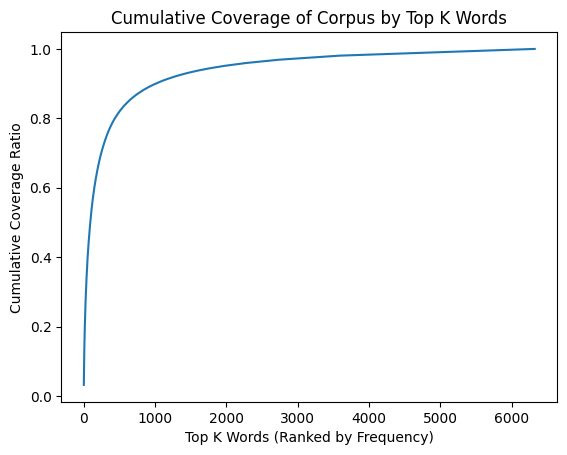

In [ ]:

all_tokens  = " ".join(df_train["Caption_clean"]).split()

word_freq   = Counter(all_tokens)
sorted_freq = np.array([count for _, count in word_freq.most_common()])
print(f" taille du vocabulaire{len(sorted_freq)}")

total_tokens      = np.sum(sorted_freq)
cumulative_tokens = np.cumsum(sorted_freq)
coverage          = cumulative_tokens / total_tokens

plt.figure()
plt.plot(coverage)
plt.xlabel("Top K Words (Ranked by Frequency)")
plt.ylabel("Cumulative Coverage Ratio")
plt.title("Cumulative Coverage of Corpus by Top K Words")
plt.show()

**Commentaire :** Le vocabulaire réel après nettoyage est d'environ 6 300 mots.
La courbe s'aplatit dès 1 000 mots (~95% de coverage) et atteint
99% autour de 3 000 mots.
on retient MAX_WORDS=5 000, qui couvre ~98% du corpus tout en restant
cohérent avec la taille réelle du vocabulaire.

In [ ]:
MAX_WORDS= 5000
ALL_LABELS  = [1,2,3,4,5,6,7,8,9,10,11,13,14,15,16,17,18,19]
NUM_CLASSES = len(ALL_LABELS)
MAX_LEN = 20

In [ ]:

y_train = np.stack(df_train["Labels"].apply(lambda x: labels_to_vector(ast.literal_eval(str(x)))).values)
y_val   = np.stack(df_val["Labels"].apply(lambda x: labels_to_vector(ast.literal_eval(str(x)))).values)
y_test  = np.stack(df_test["Labels"].apply(lambda x: labels_to_vector(ast.literal_eval(str(x)))).values)

print("y_train shape :", y_train.shape)

y_train shape : (24284, 18)


# Protocole d'évaluation

Nous utilisons le meme protocole d'évaluation utilisé pour la classification des images.

In [ ]:
THRESHOLD = 0.3
LABEL_NAMES = [
    "Personne", "Vélo", "Road/street", "Moto", "Avion", "Bus", "Train",
    "Truck", "Bateau", "Feux tricolores", "Bouche incendie",
    "Feux signalisation", "Parking meter", "Banc", "Oiseau", "Chat", "Chien", "Cheval"
]



# Tokenisation

Avant d’entraîner un modèle de classification, les données textuelles doivent être transformées en une représentation numérique exploitable. Cette étape, appelée tokenisation, consiste à découper le texte en unités élémentaires (mots, sous-mots ou caractères) appelées *tokens*.

Ces tokens sont ensuite convertis en indices ou en vecteurs numériques, permettant au modèle de traiter le texte. Cette transformation est essentielle, car les modèles de machine learning ne peuvent pas manipuler directement du texte brut.



In [ ]:


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df_train["Caption_clean"])

X_train = pad_sequences(tokenizer.texts_to_sequences(df_train["Caption_clean"]), maxlen=MAX_LEN, padding="post")
X_val   = pad_sequences(tokenizer.texts_to_sequences(df_val["Caption_clean"]),   maxlen=MAX_LEN, padding="post")
X_test  = pad_sequences(tokenizer.texts_to_sequences(df_test["Caption_clean"]),  maxlen=MAX_LEN, padding="post")

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

X_train : (24284, 20)
X_val   : (2693, 20)
X_test  : (3023, 20)


# Baseline

Comme baseline, nous utilisons une combinaison classique TF-IDF et Régression Logistique.Cette baseline est retenue pour sa simplicité, sa rapidité d'entraînement et ses performances généralement solides en classification de texte. Elle servira de référence pour évaluer le gain apporté par des approches plus avancées.

In [ ]:
tfidf = TfidfVectorizer(max_features=MAX_WORDS, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(df_train["Caption_clean"])
X_val_tfidf   = tfidf.transform(df_val["Caption_clean"])
X_test_tfidf  = tfidf.transform(df_test["Caption_clean"])

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_tfidf, y_train)

y_pred_baseline_proba = clf.predict(X_val_tfidf)


In [ ]:
y_pred_baseline = evaluate(y_val, y_pred_baseline_proba, threshold=THRESHOLD)



=== Métriques agrégées ===
F1 macro     : 0.6775
F1 micro     : 0.7995
F1 weighted  : 0.7667
F1 samples   : 0.8290

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.92      0.93      0.93      2052
              Vélo       0.88      0.29      0.43       105
       Road/street       0.63      0.27      0.38       392
              Moto       1.00      0.54      0.70       114
             Avion       1.00      0.81      0.90       102
               Bus       0.97      0.67      0.79       125
             Train       0.97      0.94      0.96       109
             Truck       0.84      0.26      0.40       199
            Bateau       1.00      0.46      0.63        94
   Feux tricolores       0.84      0.28      0.42       132
   Bouche incendie       1.00      0.43      0.60        54
Feux signalisation       0.90      0.48      0.63        54
     Parking meter       1.00      0.48      0.65        23
              

**Commentaire :**

**Label 1 (Personne)** : précision et recall équilibrés (0.92 / 0.93) — le modèle
prédit bien ce label car les captions mentionnent systématiquement un mot de
référence ("man", "woman", "group", "people").

**Label 2 (Vélo)** : précision correcte (0.88) mais recall très faible (0.29) —
le modèle détecte bien les captions mentionnant "bike" ou "bicycle" mais rate
les cas où le vélo est présent sans être l'élément central de la description.
Comportement similaire pour : Moto, Truck, Bateau, Feux tricolores,
Bouche d'incendie, Feux de signalisation, Banc, Oiseau.

**Label 3 (Road/street)** : cas différent — F1 le plus faible (0.38).
Le mot "street" est trop générique et apparaît dans presque toutes les scènes
urbaines, ce qui le rend peu discriminant pour le TF-IDF.

**Labels 17/18/19 (Chat, Chien, Cheval)** : F1 élevés (0.92 / 0.88 / 0.87) car
ces animaux sont systématiquement nommés dans les captions et ont un
vocabulaire très discriminant.

**F1 micro (0.80) vs F1 macro (0.68)** : l'écart de 0.12 confirme que le
déséquilibre des classes impacte les performances globales. Le micro est
tiré vers le haut par la classe Personne (77% des images, F1=0.93),
tandis que le macro pénalise les mauvaises performances sur les classes rares.
C'est précisément pour cette raison que le F1 macro est retenu comme métrique principale.

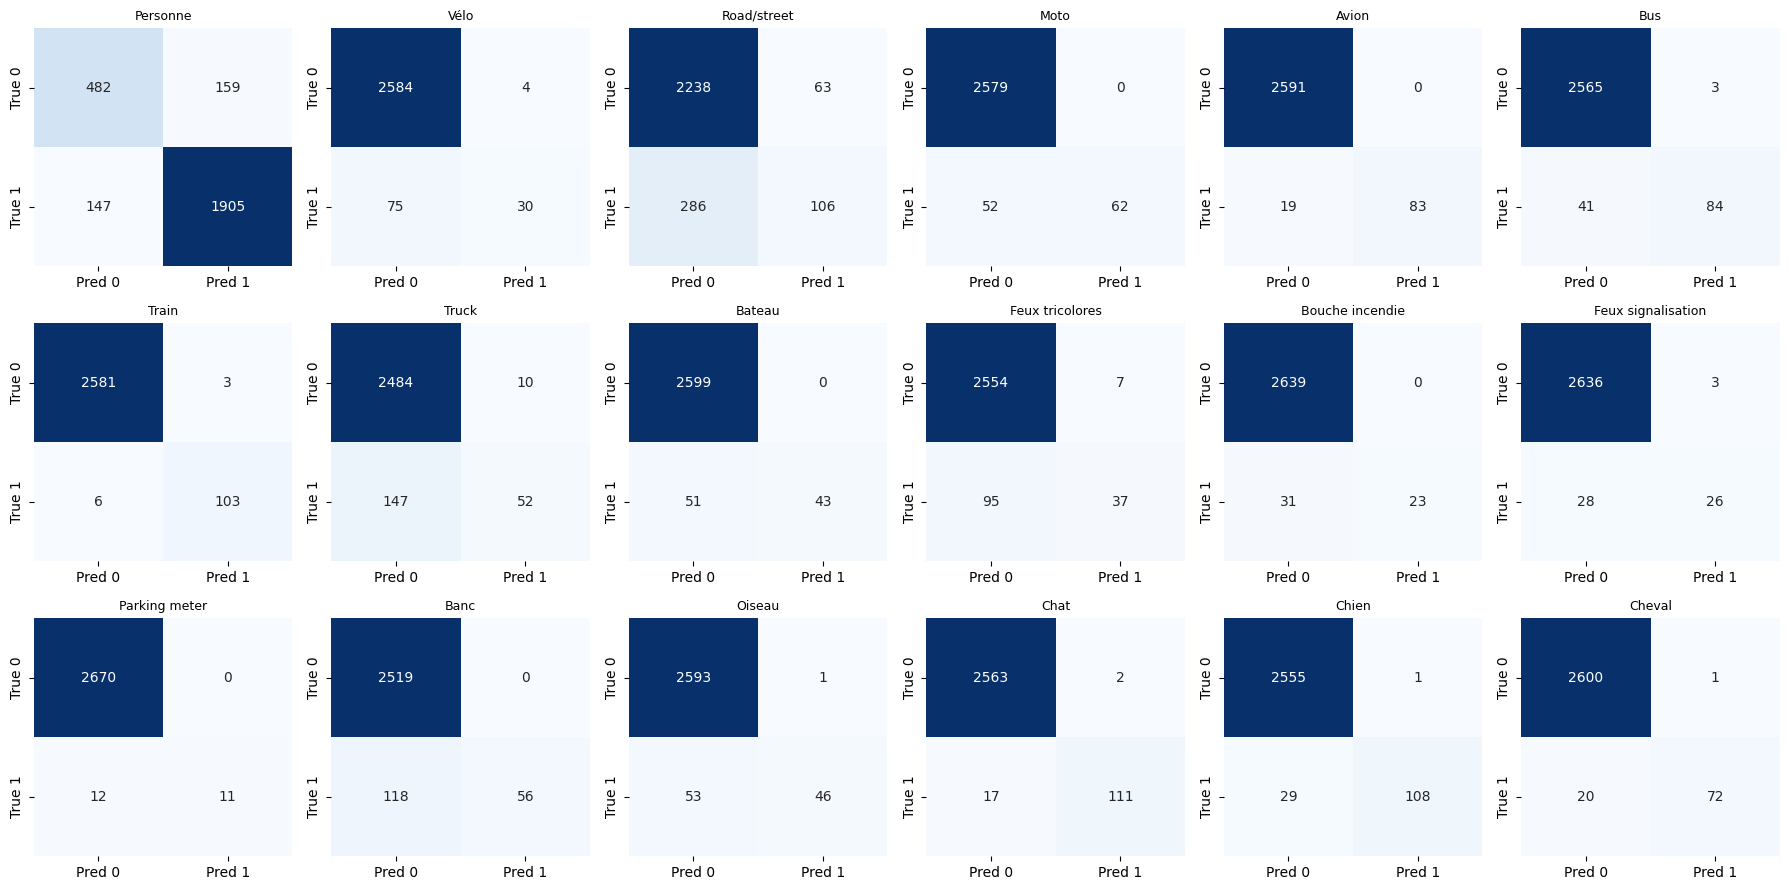

In [ ]:
plot_confusion_matrices(y_val, y_pred_baseline_proba, threshold=THRESHOLD)


**Commentaire**

Les labels Moto, Avion, Bateau, Bouche d'incendie, Parking meter, Banc
présentent 0 faux positifs. Le modèle ne se trompe jamais quand il prédit
ces labels, mais en manque une grande partie. Exemple sur Bateau :
- 2599 vrais négatifs, 0 faux positifs , précision = 1.00
- 51 faux négatifs, 43 vrais positifs , recall = 0.46

Cela confirme que le TF-IDF détecte uniquement les captions contenant
le mot exact ("boat", "ship") et rate toutes les descriptions indirectes.

Vélo, Bus, Feux tricolores, Feux de signalisation, Train, Oiseau, Chat,
Chien, Cheval présentent un nombre faible mais non nul de faux positifs,
ce qui explique une précision légèrement inférieure à 1.00 mais un recall
meilleur : le modèle est un peu moins conservateur sur ces classes.


Analysons quelques prédictions

In [ ]:
plot_predictions(df_val, y_val, y_pred_baseline_proba)


Caption : A vase filled with the Charlie Brown Christmas Tree.
Réels   : ['Oiseau']
Prédits : ['Personne']
------------------------------------------------------------
Caption : An image of the back trunk of a truck.
Réels   : ['Truck']
Prédits : ['Personne', 'Truck']
------------------------------------------------------------
Caption : A long park bench is along the path by trees.
Réels   : ['Personne', 'Banc']
Prédits : ['Banc']
------------------------------------------------------------
Caption : A man in beard and glasses with a red and white suit on.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : Two motorcycles parked in a parking lot outside a filling station.
Réels   : ['Moto']
Prédits : ['Moto']
------------------------------------------------------------


**Commentaire :**
- Le modèle prédit correctement les labels quand le mot exact est présent
  dans la caption ("motorcycles" → Moto, "man" → Personne).

- Le modèle prédit très souvent le label 1 (Personne) à tort.
  Cela s'explique par le déséquilibre des classes : Personne représente
  77% des exemples d'entraînement, ce qui pousse le modèle à le prédire
  par défaut même en l'absence de mot discriminant.

- Quand le label n'est pas verbalisé dans la caption
  ("A vase filled with the Charlie Brown Christmas Tree" → Oiseau),
  le modèle échoue complètement. C'est une limite du  TF-IDF.

# Experimentations avec des modèles de deep learning

## Métriques d'entraînement

Nous surveillons pendant l'entrainement la **AUC-PR** (Aire sous la courbe Precision/Recall) qui est indépendante du seuil et  plus adaptée que l'AUC-ROC car notre distribution est déséquilibrée

In [ ]:
def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].plot(history.history["loss"],        label="Train")
    axes[0].plot(history.history["val_loss"],     label="Validation")
    axes[0].set_title("Courbe de loss")
    axes[0].set_xlabel("Époque")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history["auc_pr"],       label="Train")
    axes[1].plot(history.history["val_auc_pr"],   label="Validation")
    axes[1].set_title("Courbe AUC-PR")
    axes[1].set_xlabel("Époque")
    axes[1].set_ylabel("AUC-PR")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## LSTM

Nous utilisons une première arhitecture simple basée sur LSTM:

* Embedding : projection de chaque token en vecteur dense de dimension 64 (vocabulaire limité à MAX_WORDS, séquences paddées à MAX_LEN).
* LSTM(128) : couche récurrente de 128 unités qui capture les dépendances séquentielles dans la caption.
* Dropout(0.3) : régularisation pour limiter le surapprentissage.
* Dense + sigmoid : couche de sortie avec activation sigmoïde par classe, adaptée au cadre multi-label.

Les valeurs classiques pour output_dim sont 32, 64, 128, 256. On commence à 64 comme compromis, et si le modèle sous-apprend on peut monter à 128. C'est un hyperparamètre.

In [ ]:
model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    LSTM(128),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[AUC(name="auc_pr",  curve="PR")]
)

model_lstm.build(input_shape=(None, MAX_LEN))
model_lstm.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,138 (1.61 MB)

 Trainable params: 421,138 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5,
                                mode="min", restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping]
)


Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - auc_pr: 0.4814 - loss: 0.2190 - val_auc_pr: 0.5056 - val_loss: 0.2012
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.4983 - loss: 0.2043 - val_auc_pr: 0.5068 - val_loss: 0.2011
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.6366 - loss: 0.1786 - val_auc_pr: 0.6663 - val_loss: 0.1666
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.7242 - loss: 0.1484 - val_auc_pr: 0.7936 - val_loss: 0.1272
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.8279 - loss: 0.1144 - val_auc_pr: 0.8382 - val_loss: 0.1108
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - auc_pr: 0.8650 - loss: 0.0992 - val_auc_pr: 0.8564 - val_loss: 0.1025
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.8827 - loss: 0.0907 - val_auc_pr: 0.8618 - val_loss: 0.1006
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - auc_pr: 0.8937 - loss: 0.0852 - val_auc_pr: 0.8623 - val_loss: 0.1005
Epoch 

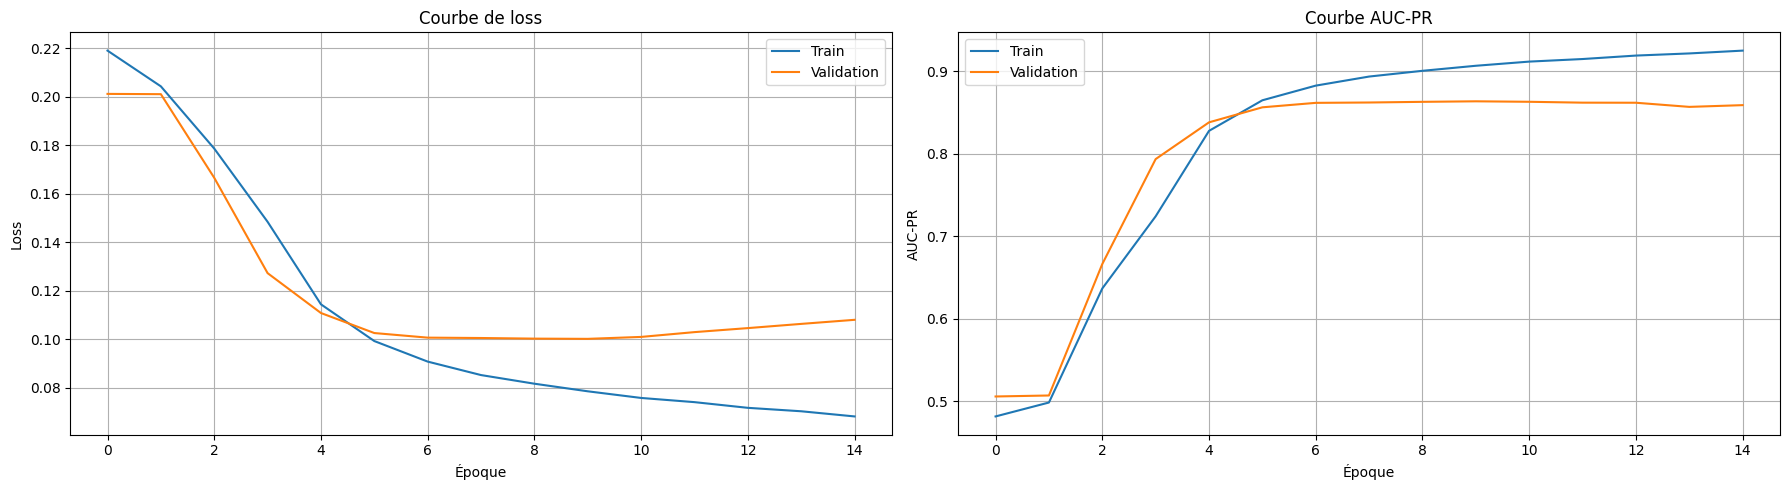

In [ ]:
plot_learning_curves(history_lstm)

**Commentaire :**

Les courbes montrent un début de surapprentissage modéré :

* Loss : Les deux courbes descendent ensemble jusqu'à l'époque 5, puis divergent — la loss train continue de baisser  tandis que la loss val se stabilise voire remonte légèrement. C'est le signe d'un overfitting qui débute.

* AUC : Les deux courbes montent ensemble jusqu'à ~0.90, puis la train continue de progresser pendant que la val plafonne . L'écart reste faible. Le modèle généralise encore correctement.

Le surapprentissage est présent mais limité. le LSTM commence à mémoriser les patterns du train après l'époque 5.

In [ ]:
y_lstm_proba = model_lstm.predict(X_val)

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_pred_lstm = evaluate(y_val, y_lstm_proba, threshold=THRESHOLD)


=== Métriques agrégées ===
F1 macro     : 0.6910
F1 micro     : 0.7854
F1 weighted  : 0.7796
F1 samples   : 0.8342

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.90      0.95      0.92      2052
              Vélo       0.60      0.39      0.47       105
       Road/street       0.42      0.55      0.47       392
              Moto       0.72      0.65      0.68       114
             Avion       0.99      0.90      0.94       102
               Bus       0.93      0.74      0.82       125
             Train       0.94      0.94      0.94       109
             Truck       0.45      0.41      0.43       199
            Bateau       0.81      0.60      0.69        94
   Feux tricolores       0.56      0.41      0.47       132
   Bouche incendie       0.74      0.46      0.57        54
Feux signalisation       0.72      0.57      0.64        54
     Parking meter       0.85      0.48      0.61        23
              

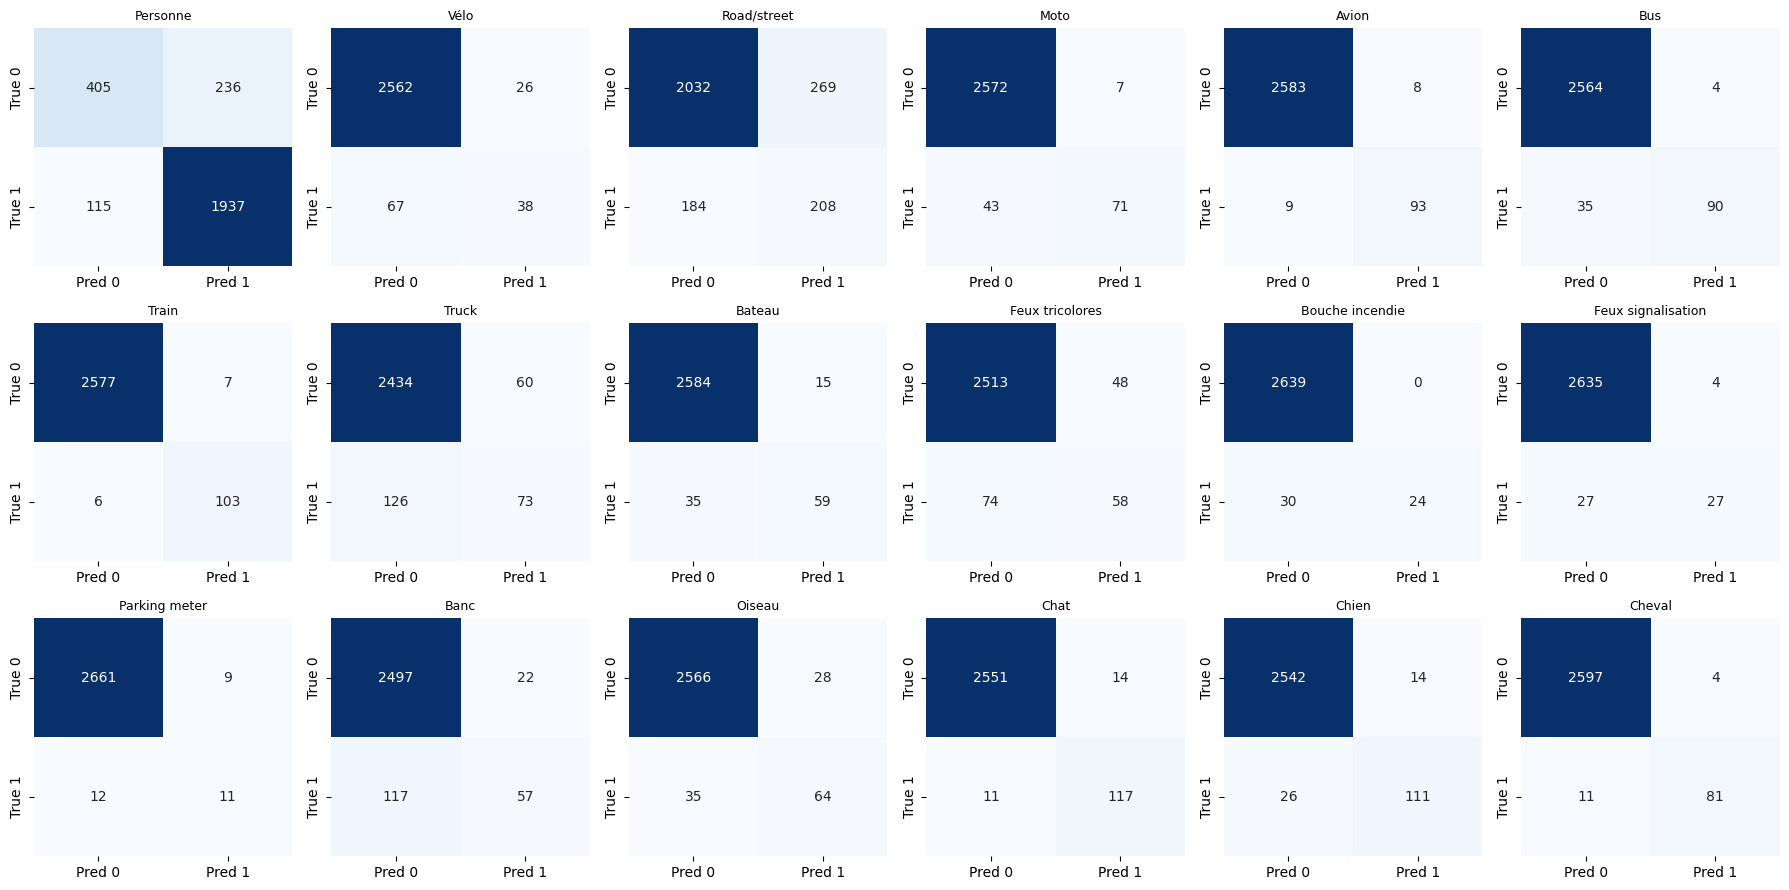

In [ ]:
plot_confusion_matrices(y_val, y_pred_lstm, threshold=THRESHOLD)


### Résultats LSTM 

| Métrique     | TF-IDF | LSTM  | Δ      |
|--------------|--------|-------|--------|
| F1 macro     | 0.677  | 0.690 | +0.013 |
| F1 micro     | 0.800  | 0.790 | -0.010 |
| F1 weighted  | 0.767  | 0.780 | +0.013 |
| F1 samples   | 0.829  | 0.830 | +0.001 |


Le LSTM améliore le F1 macro (+0.013)  par rapport
à la baseline TF-IDF. Le gain est modeste mais compréhensible vu la nature
du dataset : des captions courtes où le contexte séquentiel apporte peu.

on note :
- Bateau : (+0.06) — le contexte séquentiel aide
- Feux de signalisation : (+0.01)
- Recall global en hausse : le LSTM manque moins de labels que le TF-IDF
- Précision macro :(de  0.94 à 0.77) : le LSTM génère plus de faux positifs
- Moto :( De 0.70 à 0.68) 
- Bouche incendie : ( de 0.60 à 0.57) 


Le LSTM dépasse la baseline sur le F1 macro mais la progression reste
faible. Le pattern précision haute / recall faible persiste sur les classes
rares (Banc, Truck, Vélo) — l'optimisation des seuils par classe sera
déterminante pour améliorer ces résultats.

In [ ]:
plot_predictions(df_val, y_val, y_pred_lstm)


Caption : A demonic looking person wearing a black robe at night.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : A group of smiling people standing together holding frisbees.
Réels   : ['Personne', 'Road/street']
Prédits : ['Personne']
------------------------------------------------------------
Caption : Jets are floating on the water next to a pier.
Réels   : ['Avion', 'Bateau']
Prédits : ['Avion']
------------------------------------------------------------
Caption : A man riding a skateboard up the side of a cement ramp.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : This truck is loaded and tied down securely.
Réels   : ['Moto', 'Truck']
Prédits : ['Personne', 'Road/street', 'Truck']
------------------------------------------------------------


**Commentaires:**
- **Ex. 1 & 4 — Corrects** : captions explicites ("person", "man") bien classifiées, LSTM et TF-IDF performent de façon similaire.
- **Ex. 2 — Faux négatif Road/street** : aucun mot lié à une rue dans la caption, impossible à déduire du texte seul.
- **Ex. 3 — Faux négatif Bateau** : "Jets" détecté mais Bateau manqué car la scène est décrite sans le mentionner explicitement 
- **Ex. 5 — Biais classe majoritaire** : Truck correct mais Personne et Road/street prédits à tort. C'est le biais vers les classes fréquentes qui  persiste comme dans la baseline.

Nous allons tester  un deuxième modèle, le Bi-LSTM

# Bi-LSTM

Contrairement au LSTM, Le Bi-LSTM lit chaque caption dans les deux sens, ce qui lui permet de mieux capturer le contexte global d'un mot.
Cette lecture bidirectionnelle est particulièrement utile car les informations discriminantes sont souvent réparties sur toute la séquence.


**Architecture**

* Embedding : identique au LSTM simple

* Bidirectional LSTM(128) : avec return_sequences=True pour conserver la sortie à chaque pas de temps

* GlobalMaxPooling1D : réduit la séquence à un vecteur en ne retenant que la valeur maximale par dimension.
* Dropout(0.5) : couche de régularisation
* Dense + sigmoid : même sortie multi-label que précédemment.

In [ ]:

model_bilstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="sigmoid")
])

model_bilstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[AUC(name="auc_pr",  curve="PR") ]
)

model_bilstm.build(input_shape=(None, MAX_LEN))
model_bilstm.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,258 (1.99 MB)

 Trainable params: 522,258 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(monitor="val_loss", patience=5,
                                mode="min", restore_best_weights=True)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - auc_pr: 0.6100 - loss: 0.1931 - val_auc_pr: 0.7479 - val_loss: 0.1437
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc_pr: 0.7919 - loss: 0.1276 - val_auc_pr: 0.8282 - val_loss: 0.1146
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - auc_pr: 0.8481 - loss: 0.1070 - val_auc_pr: 0.8553 - val_loss: 0.1034
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - auc_pr: 0.8719 - loss: 0.0965 - val_auc_pr: 0.8630 - val_loss: 0.1002
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc_pr: 0.8858 - loss: 0.0896 - val_auc_pr: 0.8667 - val_loss: 0.0979
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - auc_pr: 0.8957 - loss: 0.0846 - val_auc_pr: 0.8677 - val_loss: 0.0983
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - auc_pr: 0.9019 - loss: 0.0815 - val_auc_pr: 0.8646 - val_loss: 0.0995
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc_pr: 0.9073 - loss: 0.0786 - val_auc_pr: 0.8659 - val_loss: 0.1002
E

In [ ]:
print(history_bilstm.history)

{'auc_pr': [0.6100400686264038, 0.7919296026229858, 0.8480669260025024, 0.8719140291213989, 0.8857817649841309, 0.8957072496414185, 0.9018791913986206, 0.9072664976119995, 0.9123936295509338, 0.9156466722488403], 'loss': [0.193073570728302, 0.12758873403072357, 0.1069636270403862, 0.09646095335483551, 0.08956784754991531, 0.08458119630813599, 0.08147459477186203, 0.07861997932195663, 0.07581218332052231, 0.07394932210445404], 'val_auc_pr': [0.7479188442230225, 0.8281980752944946, 0.8552730679512024, 0.8630396127700806, 0.866683840751648, 0.8676819801330566, 0.8646049499511719, 0.8658642768859863, 0.8651549220085144, 0.8635187149047852], 'val_loss': [0.14369960129261017, 0.11461645364761353, 0.10340486466884613, 0.10024707019329071, 0.09794414788484573, 0.09827397763729095, 0.09945115447044373, 0.10017117112874985, 0.10073165595531464, 0.10348352044820786]}


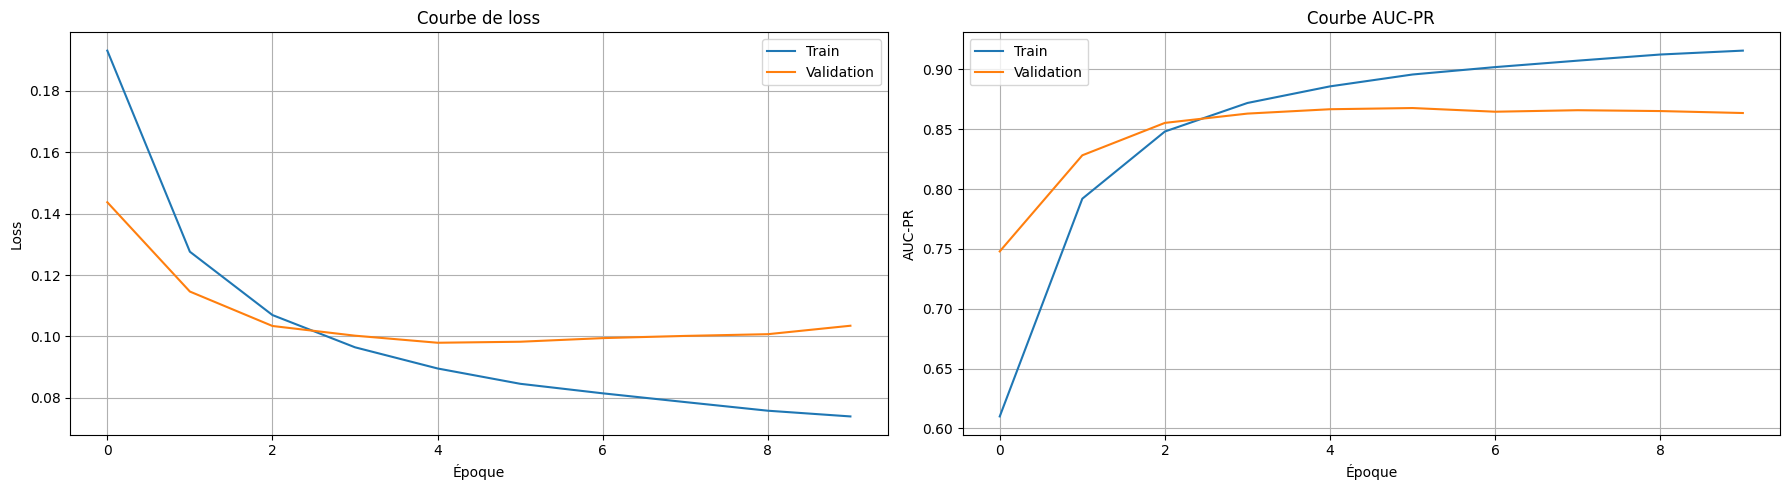

In [ ]:
plot_learning_curves(history_bilstm)

**Commentaire :**

* **Courbe de loss :**
Les deux courbes descendent ensemble jusqu'à l'époque ~5, puis divergent
nettement. La loss train continue de baisser tandis que la val loss
remonte progressivement . C'est le signal d'un overfitting.

* **Courbe AUC-PR :**
La val AUC-PR plafonne à ~0.86 dès l'époque 5 puis redescend légèrement
, tandis que la train AUC-PR continue de monter.
L'écart entre train et val confirme le surapprentissage.

Le Bi-LSTM surapprend davantage que le LSTM simple, car il est plus complexe
. Le modèle mémorise les patterns
du train après l'époque 5 sans mieux généraliser sur le val set.


In [ ]:
y_bilstm_proba = model_bilstm.predict(X_val)
y_pred_bilstm = evaluate(y_val, y_bilstm_proba, threshold=THRESHOLD)


85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== Métriques agrégées ===
F1 macro     : 0.6889
F1 micro     : 0.7957
F1 weighted  : 0.7813
F1 samples   : 0.8350

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.89      0.96      0.92      2052
              Vélo       0.76      0.28      0.41       105
       Road/street       0.46      0.51      0.49       392
              Moto       0.87      0.64      0.74       114
             Avion       1.00      0.92      0.96       102
               Bus       0.93      0.73      0.82       125
             Train       0.93      0.94      0.93       109
             Truck       0.63      0.38      0.47       199
            Bateau       0.78      0.49      0.60        94
   Feux tricolores       0.56      0.40      0.47       132
   Bouche incendie       0.96      0.43      0.59        54
Feux signalisation       0.74      0.54      0.62        54
     Parking meter       1.00      

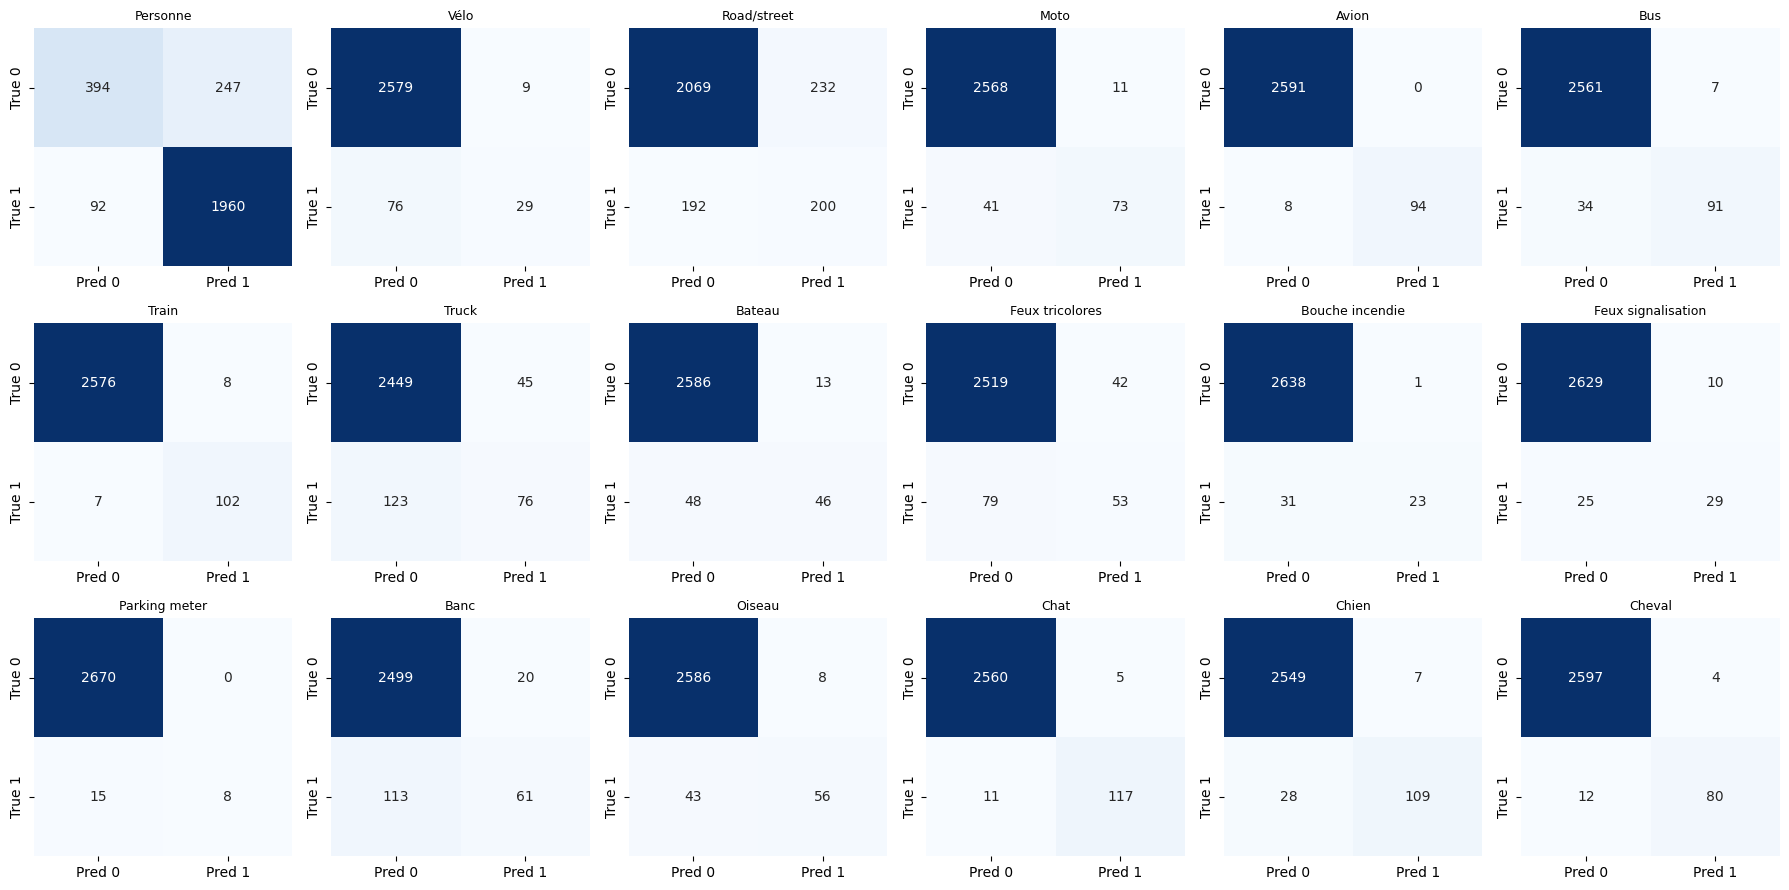

In [ ]:
plot_confusion_matrices(y_val, y_pred_bilstm, threshold=THRESHOLD)

### Résultats Bi-LSTM vs Baseline TF-IDF

| Métrique     | TF-IDF | Bi-LSTM | Δ      |
|--------------|--------|---------|--------|
| F1 macro     | 0.677  | 0.690   | +0.013 |
| F1 micro     | 0.800  | 0.800   | =      |
| F1 weighted  | 0.767  | 0.780   | +0.013 |
| F1 samples   | 0.829  | 0.840   | +0.011 |

Le Bi-LSTM améliore légèrement le F1 macro (+0.013) avec un gain notable sur Road/street (de 0.38 à 0.49) et Avion (de 0.90 à 0.96), mais au prix d'une précision macro dégradée (de 0.94 à 0.83) et de légers reculs sur Vélo et Bateau.

Le gain reste identique au LSTM simple car sur des captions courtes, la lecture bidirectionnelle n'apporte pas d'avantage significatif.

In [ ]:
plot_predictions(df_val, y_val, y_pred_bilstm)


Caption : A couple of young men playing a game of soccer.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : A passenger train is going down a train track.
Réels   : ['Road/street', 'Train', 'Feux tricolores']
Prédits : ['Train']
------------------------------------------------------------
Caption : A man who is performing a trick on a skateboard.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : A group of black sheep in a field.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : Four snow skiers are smiling at the camera.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------


**Commentaire :**

- **Ex. 1, 3, 4, 5**:  Corrects sur Personne
- **Ex. 2 ** : Train détecté, mais Road/street ("track" insuffisant) et Feux tricolores (absent de la caption) manqués


# GRU

Le GRU est une variante simplifiée du LSTM qui fusionne les portes d'oubli et d'entrée en une seule porte de mise à jour, réduisant ainsi le nombre de paramètres.

Dans le cadre de captions courtes, le GRU constitue un bon compromis entre capacité de modélisation et efficacité computationnelle.

In [ ]:
model_gru = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    GRU(128),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="sigmoid")
])

model_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[AUC(name="auc_pr", curve="PR")]
)

model_gru.build(input_shape=(None, MAX_LEN))
model_gru.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,818 (1.51 MB)

 Trainable params: 396,818 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

early_stopping = EarlyStopping(monitor="val_loss", patience=5,
                                mode="min", restore_best_weights=True)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping]
)


Epoch 1/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc_pr: 0.5304 - loss: 0.2205 - val_auc_pr: 0.6489 - val_loss: 0.1730
Epoch 2/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc_pr: 0.7184 - loss: 0.1521 - val_auc_pr: 0.8154 - val_loss: 0.1203
Epoch 3/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - auc_pr: 0.8346 - loss: 0.1125 - val_auc_pr: 0.8511 - val_loss: 0.1058
Epoch 4/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.8655 - loss: 0.0995 - val_auc_pr: 0.8625 - val_loss: 0.1009
Epoch 5/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.8805 - loss: 0.0923 - val_auc_pr: 0.8625 - val_loss: 0.1008
Epoch 6/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc_pr: 0.8915 - loss: 0.0872 - val_auc_pr: 0.8651 - val_loss: 0.1006
Epoch 7/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - auc_pr: 0.8982 - loss: 0.0834 - val_auc_pr: 0.8650 - val_loss: 0.1002
Epoch 8/30
380/380 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - auc_pr: 0.9047 - loss: 0.0803 - val_auc_pr: 0.8621 - val_loss: 0.1015
Epoch 

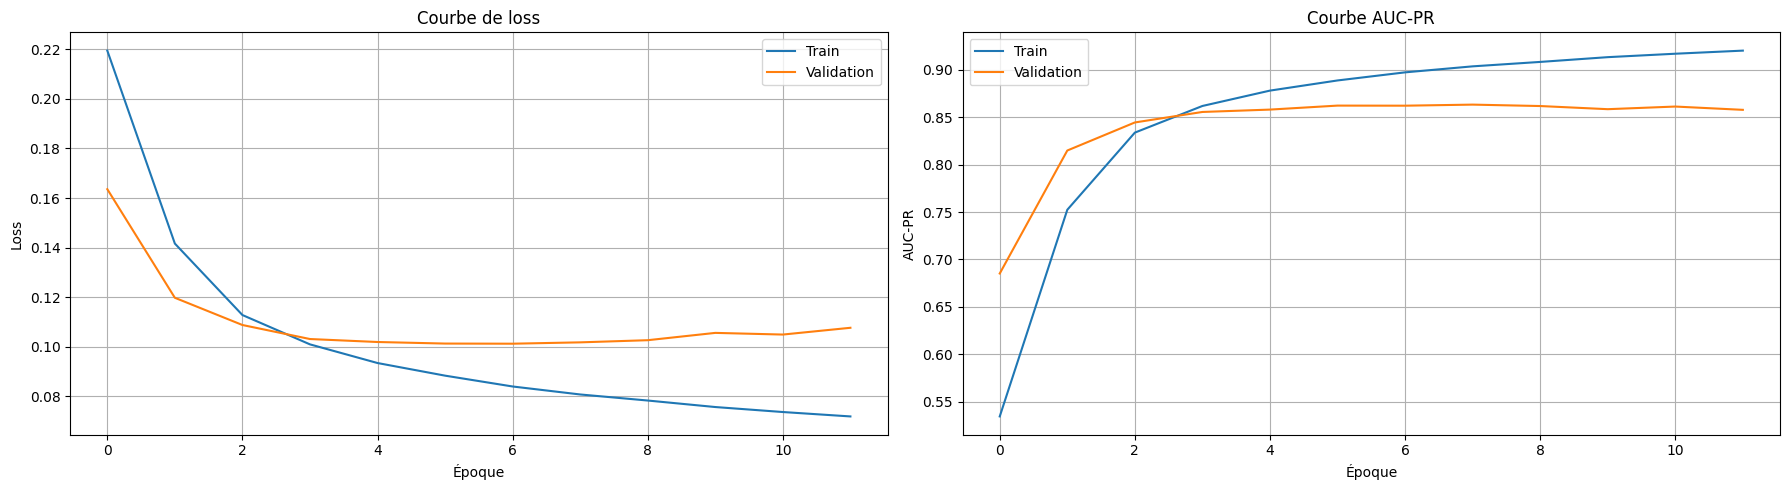

In [ ]:
plot_learning_curves(history_gru)


**Commentaire :**

On observe un overfitting modéré : divergence train/val à partir de l'époque 4, mais l'écart reste faible. Le GRU généralise mieux.L' architecture plus légère, mieux adaptée aux captions courtes. Early stopping déclenché vers l'époque 11.

In [ ]:
y_gru_proba = model_gru.predict(X_val)
y_pred_gru = evaluate(y_val, y_gru_proba, threshold=THRESHOLD)


85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Métriques agrégées ===
F1 macro     : 0.6931
F1 micro     : 0.7827
F1 weighted  : 0.7763
F1 samples   : 0.8289

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.89      0.95      0.92      2052
              Vélo       0.71      0.37      0.49       105
       Road/street       0.42      0.53      0.47       392
              Moto       0.82      0.64      0.72       114
             Avion       1.00      0.92      0.96       102
               Bus       0.93      0.74      0.82       125
             Train       0.92      0.94      0.93       109
             Truck       0.43      0.39      0.41       199
            Bateau       0.78      0.64      0.70        94
   Feux tricolores       0.44      0.41      0.43       132
   Bouche incendie       0.90      0.50      0.64        54
Feux signalisation       0.65      0.56      0.60        54
     Parking meter       0.91      

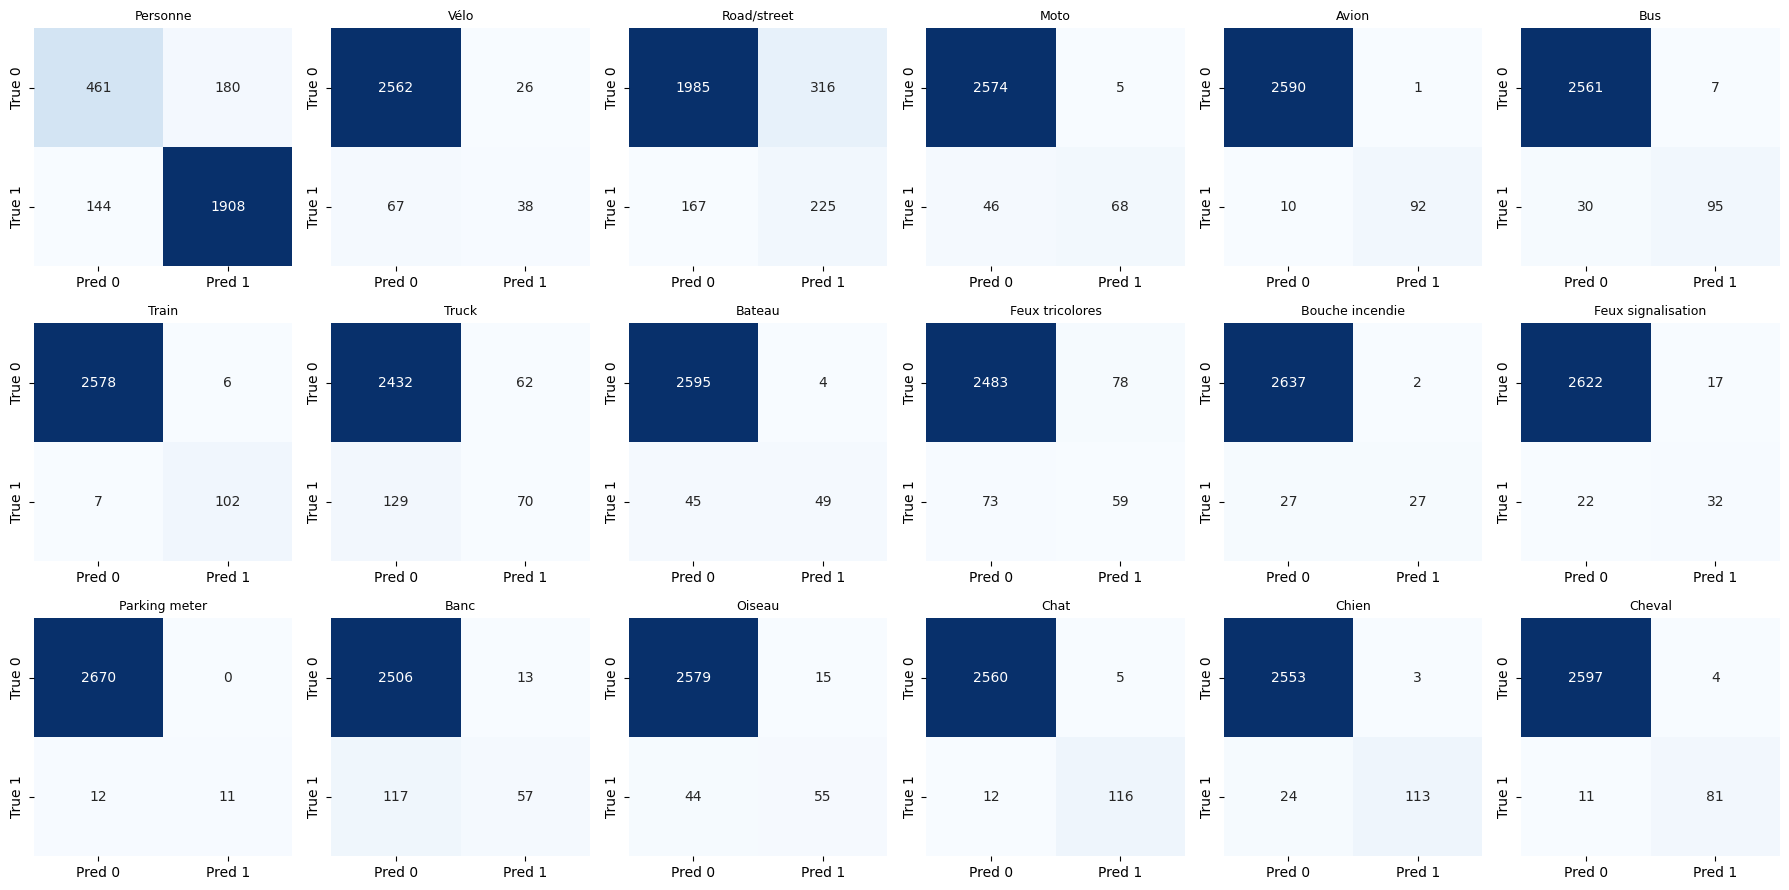

In [ ]:
plot_confusion_matrices(y_val, y_pred_gru, threshold=THRESHOLD)

### Comparaison des modèles — Classification texte

| Métrique     | TF-IDF | LSTM  | Bi-LSTM | GRU   |
|--------------|--------|-------|---------|-------|
| F1 macro     | 0.677  | 0.690 | 0.690   | 0.700 |
| F1 micro     | 0.800  | 0.790 | 0.800   | 0.787 |
| F1 weighted  | 0.767  | 0.780 | 0.780   | 0.782 |
| F1 samples   | 0.829  | 0.830 | 0.840   | 0.831 |


Les quatre modèles sont globalement équivalents. L'écart entre la
baseline TF-IDF (0.677) et le meilleur modèle GRU (0.700) est de
seulement +0.023. Cette progression marginale suggère que l'architecture
du modèle texte n'est pas le facteur limitant.


Les classes les plus difficiles ( Feux tricolores (0.44), Banc (0.47),
Truck (0.42) ) — sont mal prédites par tous les modèles, quel que
soit leur architecture. Ces labels sont rarement verbalisés dans les
captions : un modèle texte ne peut pas prédire ce qui n'est pas écrit.

C'est précisément ce qui justifie la fusion multimodale :
l'image apporte l'information visuelle que le texte ne contient pas.
Un banc en arrière-plan d'une scène urbaine sera invisible dans la
caption mais détectable par un CNN.



In [ ]:
plot_predictions(df_val, y_val, y_pred_gru)

Caption : There are six planes flying through the sky.
Réels   : ['Avion']
Prédits : ['Avion']
------------------------------------------------------------
Caption : A woman is laughing while she tries to play a game.
Réels   : ['Personne']
Prédits : ['Personne']
------------------------------------------------------------
Caption : Red and black items strapped down to flatbed trailer.
Réels   : ['Truck', 'Bouche incendie']
Prédits : ['Road/street', 'Truck']
------------------------------------------------------------
Caption : A rusted train car sit on tracks at a train station.
Réels   : ['Train']
Prédits : ['Train']
------------------------------------------------------------
Caption : A kite is being flown by a man in the distance.
Réels   : ['Personne', 'Road/street', 'Truck']
Prédits : ['Personne']
------------------------------------------------------------


**Commentaire :**

- **Ex. 1, 2, 4 — Corrects** : labels explicitement verbalisés ("planes", "train") bien détectés.
- **Ex. 3 — Faux négatif + faux positif** : Truck correct, mais Fire Hydrant manquée car les items rouges caractéristiques sont insuffisant. L label 3 (street) est  prédit à tort
- **Ex. 5 — Labels non verbalisés** : Personne détectée ("man"), street et Truck absents de la caption donc impossibles à prédire sans l'image.



### Conclusion

Le GRU est retenu comme meilleur modèle texte sur embedding aléatoire
avec un F1 macro de 0.700. Cependant, l'amélioration réelle par rapport
à la baseline TF-IDF est faible. Le texte seul atteint un plafond
sur ce dataset. La fusion multimodale est indispensable pour dépasser
ce plafond et exploiter la complémentarité entre image et texte.

Une piste d'amélioration serait d'ajouter un mécanisme d'attention
au-dessus du GRU. Cependant, sur des captions de 10 mots en moyenne,
le gain attendu est limité car l'attention est surtout utile sur des
textes longs où le contexte global est difficile à capturer.

# Optimisation avec le GRU

Améliorations à tester sur le GRU

Pour améliorer les performances nous testerons plusieurs stratégies avec le GRU:

* **Seuils par classe** : seuil fixe à 0.3 remplacé par un seuil optimisé par classe pour  améliorer le recall des classes rares.

* **Class weights** : le label Personne représente 77% des données. Les class weights pénalisent les erreurs sur les classes rares proportionnellement à leur sous-représentation.

* **Embeddings GloVe** : pré-entraîné sur 6B tokens, GloVe apporte une connaissance sémantique générale ("vessel" ≈ "boat") utile pour les classes peu verbalisées.


In [ ]:
LABEL_NAMES = [
    "Personne", "Vélo", "Road/street", "Moto", "Avion", "Bus", "Train",
    "Truck", "Bateau", "Feux tricolores", "Bouche incendie",
    "Feux signalisation", "Parking meter", "Banc", "Oiseau", "Chat", "Chien", "Cheval"
]

thresholds_gru = optimize_thresholds(y_val, y_gru_proba, LABEL_NAMES)

print("\n=== Évaluation avec seuils optimisés ===")
y_pred_opt = np.stack([
    (y_gru_proba[:, i] >= thresholds_gru[i]).astype(int)
    for i in range(NUM_CLASSES)
], axis=1)


print(classification_report(y_val, y_pred_opt, target_names=LABEL_NAMES, zero_division=0))


=== Optimisation des seuils par classe ===

Personne                  → seuil=0.55  F1=0.925
Vélo                      → seuil=0.40  F1=0.490
Road/street               → seuil=0.25  F1=0.475
Moto                      → seuil=0.60  F1=0.759
Avion                     → seuil=0.30  F1=0.959
Bus                       → seuil=0.40  F1=0.827
Train                     → seuil=0.55  F1=0.936
Truck                     → seuil=0.25  F1=0.430
Bateau                    → seuil=0.55  F1=0.723
Feux tricolores           → seuil=0.15  F1=0.456
Bouche incendie           → seuil=0.35  F1=0.651
Feux signalisation        → seuil=0.60  F1=0.659
Parking meter             → seuil=0.25  F1=0.629
Banc                      → seuil=0.15  F1=0.469
Oiseau                    → seuil=0.40  F1=0.720
Chat                      → seuil=0.75  F1=0.922
Chien                     → seuil=0.80  F1=0.892
Cheval                    → seuil=0.45  F1=0.926

=== Évaluation avec seuils optimisés ===
                    precision   

**Commentaire :**

| Métrique     | GRU seuil 0.3 | GRU seuils optimisés | Δ      |
|--------------|---------------|----------------------|--------|
| F1 macro     | 0.700         | **0.710**            | +0.010 |
| F1 micro     | 0.787         | 0.780                | -0.007 |
| F1 weighted  | 0.782         | 0.790                | +0.008 |
| F1 samples   | 0.831         | 0.820                | -0.011 |


L'optimisation des seuils améliore le trade-off précision/recall mais ne change pas la capacité du modèle à discriminer les classes. Si le modèle attribue des probabilités faibles à Banc et Feux tricolores, baisser le seuil à 0.15 augmente le recall mais dégrade fortement la précision. le F1 reste plafonné.

Le gain en F1 macro est modeste (+0.010).

### Optimisation des poids

In [ ]:
class_counts  = y_train.sum(axis=0)
class_weights = len(y_train) / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.mean()

class_weight_dict = {i: class_weights[i] for i in range(NUM_CLASSES)}



### Embedding GloVe pré-entraîné avec fine-tuning

Les modèles précédents utilisaient un embedding entraîné from scratch. 
Les vecteurs de mots étaient initialisés aléatoirement et appris uniquement sur le dataset. Ici, on initialise l'embedding avec les vecteurs GloVe, puis on le laisse se réajuster pendant l'entraînement. L'idée est de partir d'une représentation sémantique riche pour mieux généraliser, notamment sur les mots rares ou peu représentés dans le dataset.

In [1]:
import kagglehub
path = kagglehub.dataset_download("watts2/glove6b50dtxt")
print(path)

100%|██████████| 67.7M/67.7M [00:01<00:00, 70.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/watts2/glove6b50dtxt/versions/1


In [ ]:
!ls /root/.cache/kagglehub/datasets/watts2/glove6b50dtxt/versions/1

glove.6B.50d.txt


In [2]:
embeddings_index = {}
with open("/root/.cache/kagglehub/datasets/watts2/glove6b50dtxt/versions/1/glove.6B.50d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector
print(f"Vecteurs GloVe chargés : {len(embeddings_index)}")


NameError: name 'np' is not defined

In [ ]:
EMBEDDING_DIM = 50
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
found, not_found  = 0, 0

for word, i in tokenizer.word_index.items():
    if i < MAX_WORDS:
        vector = embeddings_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector
            found += 1
        else:
            not_found += 1

print(f"Mots trouvés dans GloVe : {found}")
print(f"Mots non trouvés (OOV)  : {not_found}")

Mots trouvés dans GloVe : 4825
Mots non trouvés (OOV)  : 174


### Visualisation des similarités entre embeddings GloVe

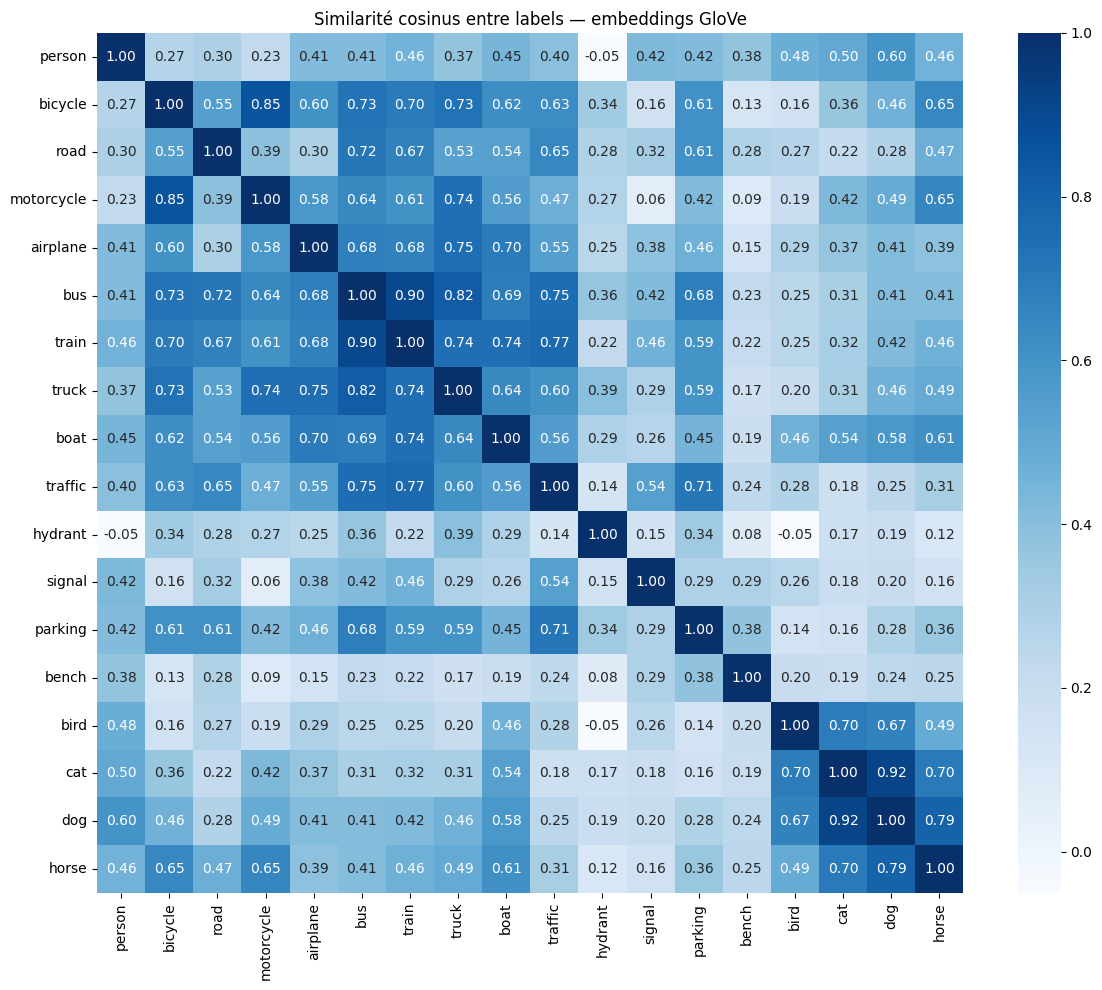

In [ ]:

sim_matrix = cosine_similarity(vectors)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words,
            annot=True, fmt=".2f", cmap="Blues")
plt.title("Similarité cosinus entre labels — embeddings GloVe")
plt.tight_layout()
plt.show()

### Similarité cosinus entre labels — Embeddings GloVe

- **Animaux** (cat, dog, horse, bird) : similarités très élevées (cat/dog 0.92, bicycle/motorcycle 0.85). Ces champ sémantique sont bien capturé par GloVe.
- **Véhicules** (bus, train, truck, bicycle, motorcycle) : même constat (bus/train 0.90, bus/truck 0.82).
- **Urbain** (traffic, road, parking) : proximités cohérentes mais plus modérées (0.65–0.71).
- **Labels isolés** : `hydrant` et `signal` sont sémantiquement éloignés de tous les autres labels. Ce qui explique en partie les faibles performances du modèle sur ces classes.


### Construction du modèle

In [ ]:
model_gru_glove = Sequential([
    Embedding(input_dim=MAX_WORDS,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),
    GRU(128),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="sigmoid")
])


In [ ]:

model_gru_glove.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[AUC(name="auc_pr", curve="PR")]
)

history_glove_p1 = model_gru_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5,
                              mode="min", restore_best_weights=True)]
)



Epoch 1/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 31s 75ms/step - auc_pr: 0.5961 - loss: 0.2019 - val_auc_pr: 0.7658 - val_loss: 0.1382
Epoch 2/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - auc_pr: 0.8037 - loss: 0.1250 - val_auc_pr: 0.8471 - val_loss: 0.1078
Epoch 3/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - auc_pr: 0.8470 - loss: 0.1083 - val_auc_pr: 0.8627 - val_loss: 0.1010
Epoch 4/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - auc_pr: 0.8622 - loss: 0.1015 - val_auc_pr: 0.8686 - val_loss: 0.0977
Epoch 5/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - auc_pr: 0.8706 - loss: 0.0974 - val_auc_pr: 0.8720 - val_loss: 0.0967
Epoch 6/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - auc_pr: 0.8753 - loss: 0.0951 - val_auc_pr: 0.8756 - val_loss: 0.0937
Epoch 7/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - auc_pr: 0.8799 - loss: 0.0928 - val_auc_pr: 0.8751 - val_loss: 0.0954
Epoch 8/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - auc_pr: 0.8824 - loss: 0.0913 - val_auc_pr: 0.8767 - val_loss:

In [ ]:
model_gru_glove.layers[0].trainable = True
model_gru_glove.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[ AUC(name="auc_pr", curve="PR")]
)



In [ ]:
history_glove_p2 = model_gru_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5,
                              mode="min", restore_best_weights=True)]
)

Epoch 1/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - auc_pr: 0.9006 - loss: 0.0818 - val_auc_pr: 0.8809 - val_loss: 0.0915
Epoch 2/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - auc_pr: 0.9015 - loss: 0.0812 - val_auc_pr: 0.8802 - val_loss: 0.0917
Epoch 3/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - auc_pr: 0.9038 - loss: 0.0801 - val_auc_pr: 0.8802 - val_loss: 0.0923
Epoch 4/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - auc_pr: 0.9041 - loss: 0.0799 - val_auc_pr: 0.8799 - val_loss: 0.0921
Epoch 5/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - auc_pr: 0.9050 - loss: 0.0794 - val_auc_pr: 0.8804 - val_loss: 0.0923
Epoch 6/15
380/380 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - auc_pr: 0.9064 - loss: 0.0787 - val_auc_pr: 0.8796 - val_loss: 0.0927


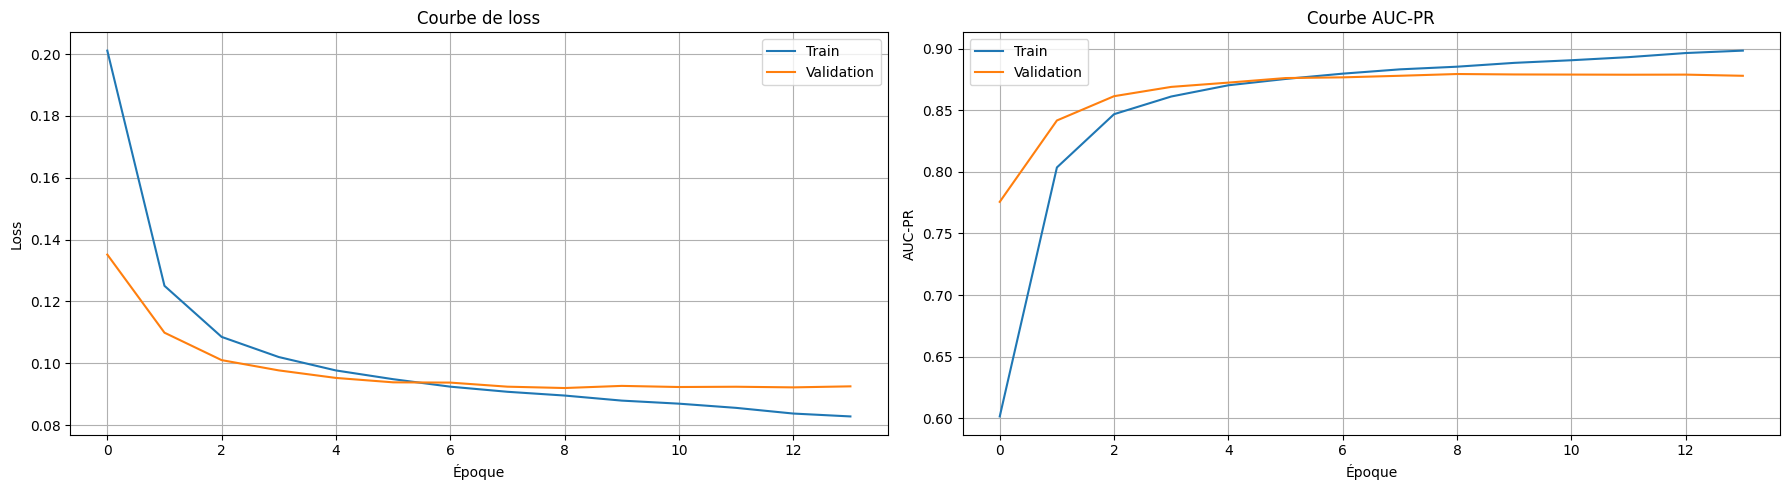

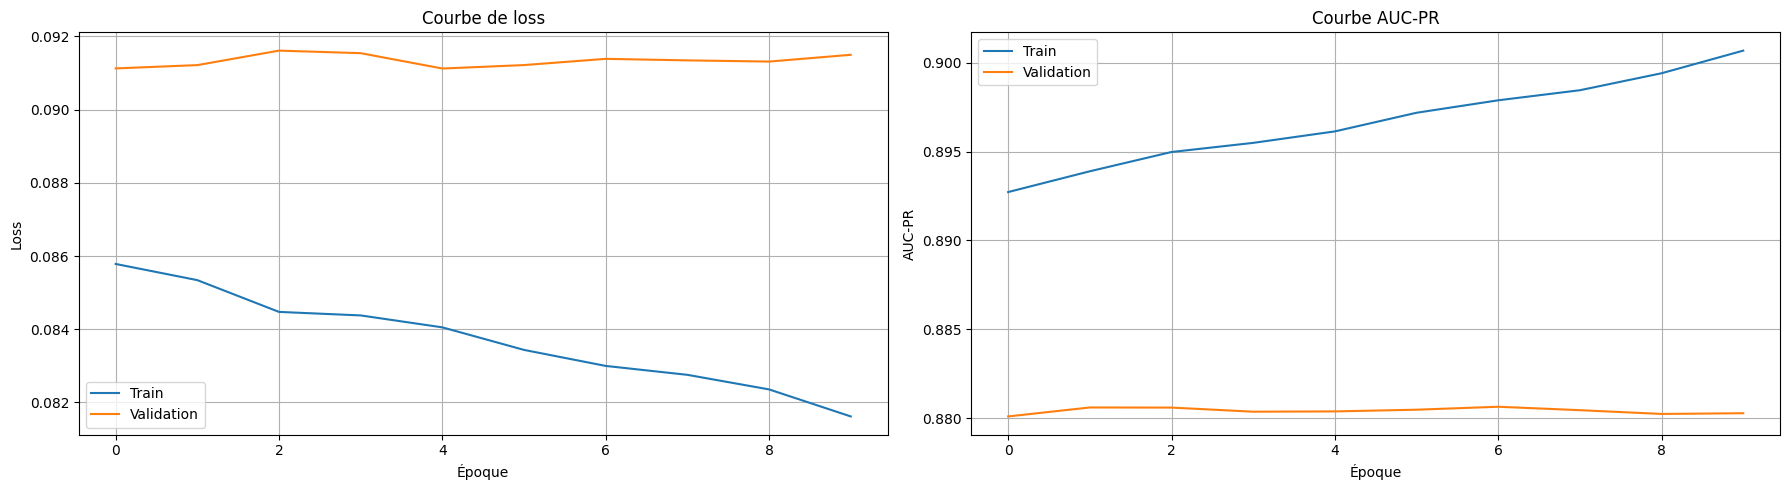

In [ ]:
plot_learning_curves(history_glove_p1)
plot_learning_curves(history_glove_p2)


**Phase 1**:Les courbes train et val convergent rapidement et restent très proches: bon apprentissage sans overfitting.
La val précède même le train en AUC-PR sur les premières époques,
signe que les embeddings GloVe pré-entraînés généralisent bien dès le départ.

**Phase 2 :** On observe un Overfitting modéré.

In [ ]:
y_proba_glove_val = model_gru_glove.predict(X_val)
evaluate(y_val, y_proba_glove_val)

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
=== Métriques agrégées ===
F1 macro     : 0.7276
F1 micro     : 0.8061
F1 weighted  : 0.7973
F1 samples   : 0.8473

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.89      0.95      0.92      2052
              Vélo       0.75      0.44      0.55       105
       Road/street       0.47      0.53      0.50       392
              Moto       0.87      0.67      0.76       114
             Avion       0.99      0.91      0.95       102
               Bus       0.93      0.72      0.81       125
             Train       0.95      0.94      0.95       109
             Truck       0.54      0.41      0.47       199
            Bateau       0.86      0.65      0.74        94
   Feux tricolores       0.58      0.45      0.51       132
   Bouche incendie       0.96      0.50      0.66        54
Feux signalisation       0.84      0.57      0.68        54
     Parking meter       1.00      

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

In [ ]:
thresholds_glove = optimize_thresholds(y_val, y_proba_glove_val, LABEL_NAMES)

=== Optimisation des seuils par classe ===

Personne                  → seuil=0.60  F1=0.929
Vélo                      → seuil=0.30  F1=0.554
Road/street               → seuil=0.30  F1=0.499
Moto                      → seuil=0.45  F1=0.766
Avion                     → seuil=0.10  F1=0.960
Bus                       → seuil=0.55  F1=0.822
Train                     → seuil=0.65  F1=0.954
Truck                     → seuil=0.25  F1=0.474
Bateau                    → seuil=0.30  F1=0.739
Feux tricolores           → seuil=0.25  F1=0.519
Bouche incendie           → seuil=0.35  F1=0.667
Feux signalisation        → seuil=0.30  F1=0.681
Parking meter             → seuil=0.20  F1=0.647
Banc                      → seuil=0.50  F1=0.515
Oiseau                    → seuil=0.60  F1=0.728
Chat                      → seuil=0.70  F1=0.931
Chien                     → seuil=0.55  F1=0.906
Cheval                    → seuil=0.30  F1=0.931


In [ ]:
evaluate(y_val, y_proba_glove_val, threshold=thresholds_glove)

=== Métriques agrégées ===
F1 macro     : 0.7346
F1 micro     : 0.8071
F1 weighted  : 0.8036
F1 samples   : 0.8443

=== Métriques par classe ===
                    precision    recall  f1-score   support

          Personne       0.95      0.91      0.93      2052
              Vélo       0.75      0.44      0.55       105
       Road/street       0.47      0.53      0.50       392
              Moto       0.97      0.63      0.77       114
             Avion       0.98      0.94      0.96       102
               Bus       0.99      0.70      0.82       125
             Train       0.96      0.94      0.95       109
             Truck       0.49      0.46      0.47       199
            Bateau       0.86      0.65      0.74        94
   Feux tricolores       0.52      0.52      0.52       132
   Bouche incendie       1.00      0.50      0.67        54
Feux signalisation       0.84      0.57      0.68        54
     Parking meter       1.00      0.48      0.65        23
              

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

## Tableau comparatif final de tous les modèles

| Métrique     | TF-IDF | LSTM  | Bi-LSTM | GRU   | GRU+seuils | GRU+GloVe | GRU+GloVe+seuils |
|--------------|--------|-------|---------|-------|------------|-----------|------------------|
| F1 macro     | 0.677  | 0.690 | 0.690   | 0.700 | 0.710      | 0.719     | **0.736**        |
| F1 micro     | 0.800  | 0.790 | 0.800   | 0.787 | 0.780      | 0.802     | 0.800            |
| F1 weighted  | 0.767  | 0.780 | 0.780   | 0.782 | 0.790      | 0.792     | 0.802            |
| F1 samples   | 0.829  | 0.830 | 0.840   | 0.831 | 0.820      | 0.846     | 0.842            |


* Le  GRU avec embedding  GloVe et seuils optimisés est le meilleur modèle avec un
F1 macro de 0.736. C'est une progression de +0.059 par rapport à la baseline
TF-IDF et +0.036 par rapport au GRU seul.


* On note aussi une progression des classes vélo (+0.12), Feux tricolores (+0.10),Bateau(+0.12) et Feux signalisation(+0.08)  par rapport à la baseline.


* Par contre, On ne note pas d'amélioration sur les classes Truck,Banc et street car ces labels sont non verbalisés dans les caption


In [ ]:
model_gru_glove.save("model_texte_final.h5")
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

thresholds_dict = {LABEL_NAMES[i]: float(thresholds_glove[i])
                   for i in range(NUM_CLASSES)}
with open("thresholds_texte.json", "w") as f:
    json.dump(thresholds_dict, f, indent=2)

print("Sauvegarde terminée.")

Sauvegarde terminée.


# Explication du modèle

LIME (*Local Interpretable Model-agnostic Explanations*) permet d'interpréter localement les prédictions du modèle en identifiant les mots qui ont le plus contribué à chaque prédiction. Pour chaque exemple, LIME génère des perturbations de la caption (en masquant des mots) et observe l'impact sur la sortie du modèle. Les mots les plus influents sont alors mis en évidence.

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=778eaa7dedf3fc11b5f9f2939adeca8e431815f4e14c79864afcd01daaaff326
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
explainer = LimeTextExplainer(class_names=LABEL_NAMES)


In [ ]:
idx     = 0
text    = df_val["Caption_clean"].iloc[idx]
print(f"Caption   : {df_val['Caption'].iloc[idx]}")
print(f"Réels     : {[LABEL_NAMES[i] for i in range(NUM_CLASSES) if y_val[idx][i] == 1]}")

label_idx = LABEL_NAMES.index("Personne")

exp = explainer.explain_instance(
    text,
    predict_proba_lime,
    num_features=10,
    labels=[label_idx]
)

exp.show_in_notebook(text=True)

Caption   : Woman in swim suit holding parasol on sunny day.
Réels     : ['Personne']
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


LIME confirme que le mot **"woman"** est le contributeur dominant (0.17), suivi de "holding" et "day" avec un impact marginal. Les mots "swim", "suit" et "parasol" n'ont aucun poids le modèle s'appuie quasi exclusivement sur la référence directe à une personne, sans exploiter le contexte de la scène.

In [ ]:
explain_prediction(0, "Personne")
explain_prediction(10, "Bateau")
explain_prediction(50, "Chien")

Caption : Woman in swim suit holding parasol on sunny day.
Réels   : ['Personne']
Label expliqué : Personne
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


Caption : Cat Siamese looking sleeping on its side on a comforter.
Réels   : ['Chat']
Label expliqué : Bateau
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Caption : Large grassy pasture filled with trees and a single horse.
Réels   : ['Cheval']
Label expliqué : Chien
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Exemple LIME — *"Cat Siamese looking sleeping on its side on a comforter"*

Prédiction correcte, mais LIME affiche des poids nuls sur tous les mots. Cela s'explique probablement par la **très haute confiance du modèle** (prob = 1.00). Les perturbations de LIME n'ont pas d'impact mesurable sur une prédiction aussi certaine, ce qui rend l'explication peu informative.

### Exemple LIME — *"Large grassy pasture filled with trees and a single horse"*

Prédiction correcte. LIME montre que **"horse"** est le seul mot contributeur , tous les autres mots étant à 0.00. Le modèle s'appuie quasi exclusivement sur la présence du mot exact "horse". Les faux positifs sur Personne (0.23) et street (0.16) confirment le biais persistant vers les classes fréquentes, sans ancrage lexical identifiable dans la caption.